In [21]:
import os

# Change to a new directory
new_path = r"/home/sdutta/code/random-matrix"
os.chdir(new_path)
# print(os.getcwd())
import matplotlib.pyplot as plt
from math import factorial
import scipy
import quadpy
from scipy.special import hankel1, spherical_jn, lpmv, h1vp
from scipy.integrate import quad, dblquad
from scipy.spatial import ConvexHull
import numpy as np
import cupy as cp
from random_matrix.utils import integration_utils as iu
import math
from tqdm import tqdm
from functools import lru_cache
import cProfile
from typing import Callable, Any
def pi_tau_mn(m, n, theta):
    if isinstance(theta, (list, np.ndarray)):
        theta[theta == 0] = np.sqrt(
            2 * np.finfo(np.float64).eps
        )  # remove issues with divide by zero
        theta[theta == np.pi] = np.pi + np.sqrt(
            2 * np.finfo(np.float64).eps
        )  # remove issues with divide by zero

    elif isinstance(theta, int):
        if theta == 0:
            theta = np.sqrt(2 * np.finfo(np.float64).eps)
        elif theta == np.pi:
            theta = np.pi + np.sqrt(2 * np.finfo(np.float64).eps)

    Ln = lpmv(m, n, np.cos(theta))
    Lnp1 = lpmv(m, n + 1, np.cos(theta))

    norm =(np.sqrt(factorial(n - m) / factorial(n + m)))
    pi_out =norm* m*Ln / (np.sin(theta))
    tau_out = norm * (
        -(1+n) * np.cos(theta) * Ln/(np.sin(theta))
        + (1-m+ n) * Lnp1/np.sin(theta)
    )

    return (pi_out,tau_out)


@lru_cache(maxsize=None)  # Memoize for all (m, n) pairs
def const_mn(m, n):

    return ((-1) ** (m)) * np.sqrt(factorial(n + m) / factorial(n - m))


@lru_cache(maxsize=None)  # Memoize for all (m, n) pairs
def gamma_mn(m, n):
    if n == 0:  # To avoid division by zero
        return 0
    return np.sqrt(
        ((2 * n + 1) * factorial(n - m)) / (4 * np.pi * n * (n + 1) * factorial(n + m))
    )


# @staticmethod
def B_mn(m, n, theta, phi):
    c = const_mn(m, n) * np.exp(1j * m * phi)

    pitaumn = pi_tau_mn(m, n, theta)
    theta_comp = c * pitaumn[1]
    phi_comp = 1j * c * pitaumn[0]
    return (theta_comp, phi_comp)


def C_mn(m, n, theta, phi):
    c = const_mn(m, n) * np.exp(1j * m * phi)

    pitaumn = pi_tau_mn(m, n, theta)
    theta_comp = 1j * c * pitaumn[0]
    phi_comp = -c * pitaumn[1]
    return (theta_comp, phi_comp)


def cart2sph(x, y, z):
    xy = x**2 + y**2
    r = np.sqrt(xy + z**2)
    t = np.pi / 2 - np.arctan2(z, np.sqrt(xy))
    p = np.arctan2(y, x)
    if np.all(p < 0):
        p = p + 2 * np.pi

    return (r, t, p)


def d_mn(m, n, theta):
    x = np.cos(theta)
    lp = lpmv(m, n, x)
    return lp * (np.sqrt(factorial(n - m) / factorial(n + m)))


# Function returns the spherical Bessel functions
def j_n(n, kr):
    return spherical_jn(n, kr)


# Function reutrns Hankel function of 1st kind
def h_n(n, kr):
    return hankel1(n, kr)


def P_mn(m, n, theta, phi):
    c = const_mn(m, n) * np.exp(1j * m * phi)
    return c * d_mn(m, n, theta)


def RgM_mn(m, n, kr, theta, phi):
    gamma = gamma_mn(m, n)  # Cached value
    Cmn = C_mn(m, n, theta, phi)
    theta_comp = gamma * j_n(n, kr) * Cmn[0]
    phi_comp = gamma * j_n(n, kr) * Cmn[1]

    return np.array([theta_comp, phi_comp], dtype=np.complex128)


def RgN_mn(m, n, kr, theta, phi):
    gamma = gamma_mn(m, n)
    r_comp = gamma * n * (n + 1) / kr * spherical_jn(n, kr) * P_mn(m, n, theta, phi)
    theta_comp = (
        gamma
        * (spherical_jn(n, kr) / kr + spherical_jn(n, kr, derivative=True))
        * B_mn(m, n, theta, phi)[0]
    )
    phi_comp = (
        gamma
        * (spherical_jn(n, kr) / kr + spherical_jn(n, kr, derivative=True))
        * B_mn(m, n, theta, phi)[1]
    )

    return np.array([r_comp, theta_comp, phi_comp])


def N_mn(m, n, kr, theta, phi):
    gamma = gamma_mn(m, n)
    Bmn = B_mn(m, n, theta, phi)
    r_comp = gamma * (n * (n + 1) / kr) * hankel1(n, kr) * P_mn(m, n, theta, phi)
    theta_comp = gamma * (hankel1(n, kr) / kr + h1vp(n, kr, n=1)) * Bmn[0]
    phi_comp = gamma * (hankel1(n, kr) / kr + h1vp(n, kr, n=1)) * Bmn[1]

    return np.array([r_comp, theta_comp, phi_comp], dtype=np.complex128)


def M_mn(m, n, kr, theta, phi):
    gamma = gamma_mn(m, n)  # Cached value
    Cmn = C_mn(m, n, theta, phi)
    theta_comp = gamma * h_n(n, kr) * Cmn[0]
    phi_comp = gamma * h_n(n, kr) * Cmn[1]
    return np.array([theta_comp, phi_comp], dtype=np.complex128)


def sph2cart_comp_mat(theta, phi):
    R = np.array(
        [
            [
                np.cos(phi) * np.sin(theta),
                np.cos(phi) * np.cos(theta),
                -np.sin(phi),
            ],
            [
                np.sin(phi) * np.sin(theta),
                np.sin(phi) * np.cos(theta),
                np.cos(phi),
            ],
            [np.cos(theta), -np.sin(theta), 0 * theta],
        ]
    )

    return R


def sph2cart_comp_vec(U, theta, phi):
    R = sph2cart_comp_mat(theta, phi)
    Uout = np.einsum("mn...,n...->m...", R, U)
    return Uout


def compute_Js():
    wavelength1 = 532e-9
    k1 = (2 * np.pi) / wavelength1
    wavelength2 = 266e-9
    k2 = 1.5 * k1
    n_max = 2 
    row =50
    col = 51
    num_linear = row * col
    theta = np.linspace(0, np.pi, col)
    phi = np.linspace(0, 2 * np.pi, row)
    theta_grid, phi_grid = np.meshgrid(theta, phi)
    r = 600e-9  # particle size is 50nm
    modes = sum(2 * n + 1 for n in range(1, n_max + 1))
    # modes for exterior region (m,n)
    # For a given n m runs from -n to +n
    modes_nm = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]
    # modes for the interior region (m',n')
    modes_nmp = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]

    j11 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    j12 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    j21 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    j22 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    Rgj11 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    Rgj12 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    Rgj21 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    Rgj22 = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
    # Calculate x, y, z coordinates for the sphere
    x = np.reshape((r * np.sin(theta_grid) * np.cos(phi_grid)), (1, num_linear))
    y = np.reshape((r * np.sin(theta_grid) * np.sin(phi_grid)), (1, num_linear))
    z = np.reshape((r * np.cos(theta_grid)), (1, num_linear))
    points = np.transpose(np.vstack((x, y, z)))

    # Compute the convex hull
    hull = ConvexHull(points)
    print(hull.simplices.shape)
    for i in range(0,modes):  # for each mode in the interior region
        for j in tqdm(range(0,modes)):  # for each mode in the exterior region
            for simplex in hull.simplices:
                triangle = points[simplex]
                vertex = triangle[0]
                v1 = triangle[1] - triangle[0]
                v2 = triangle[2] - triangle[0]
                normal_cart = np.cross(v1, v2)
                normal_cart /= np.linalg.norm(normal_cart)
                dot_prod = np.dot(normal_cart, vertex)
                if dot_prod < 0:
                    normal_cart *= -1

                JJ = np.array(
                    [
                        [np.dot(v1, v1), np.dot(v1, v2)],
                        [np.dot(v2, v1), np.dot(v2, v2)],
                    ]
                )
                G = np.sqrt(np.linalg.det(JJ))

                def integrandj11(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgM = RgM_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    # RgM = np.hstack((np.zeros(6),RgM))
                    M = M_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgM[0] * M[1] - RgM[1] * M[0]
                    theta_comp = 0 * M[1]
                    phi_comp = 0 * RgM[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandj12(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgM = RgM_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    N = N_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgM[0] * N[2] - RgM[1] * N[1]
                    theta_comp = RgM[1] * N[0]
                    phi_comp = -RgM[0] * N[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandj21(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgN = RgN_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    M = M_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgN[1] * M[1] - RgN[2] * M[0]
                    theta_comp = -RgN[0] * M[1]
                    phi_comp = RgN[0] * M[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandj22(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgN = RgN_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    
                    N = N_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgN[1] * N[2] - RgN[2] * N[1]
                    theta_comp = -RgN[0] * N[2] + RgN[2] * N[0]
                    phi_comp = RgN[0] * N[1] - RgN[1] * N[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)
                def integrandRgj11(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgM1 = RgM_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    # RgM = np.hstack((np.zeros(6),RgM))
                    RgM2 = RgM_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgM1[0] * RgM2[1] - RgM1[1] * RgM2[0]
                    theta_comp = 0 * RgM2[1]
                    phi_comp = 0 * RgM1[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandRgj12(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgM = RgM_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    RgN = RgN_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgM[0] * RgN[2] - RgM[1] * RgN[1]
                    theta_comp = RgM[1] * RgN[0]
                    phi_comp = -RgM[0] * RgN[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandRgj21(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgN = RgN_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    RgM = RgM_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgN[1] * RgM[1] - RgN[2] * RgM[0]
                    theta_comp = -RgN[0] * RgM[1]
                    phi_comp = RgN[0] * RgM[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                def integrandRgj22(a, b):

                    x = vertex[0] + a * v1[0] + b * v2[0]
                    y = vertex[1] + a * v1[1] + b * v2[1]
                    z = vertex[2] + a * v1[2] + b * v2[2]
                    r, theta, phi = cart2sph(x, y, z)

                    RgN1 = RgN_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
                    
                    RgN2 = RgN_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

                    r_comp = RgN1[1] * RgN2[2] - RgN1[2] * RgN2[1]
                    theta_comp = -RgN1[0] * RgN2[2] + RgN1[2] * RgN2[0]
                    phi_comp = RgN1[0] * RgN2[1] - RgN1[1] * RgN2[0]
                    cross_prod = np.array([r_comp, theta_comp, phi_comp])
                    cp_cart = sph2cart_comp_vec(
                        cross_prod, theta, phi
                    )  # do not normalise

                    return np.dot(normal_cart, cp_cart)

                j12[j][i] += G * iu.basic_triangle_integral(
                    integrandj12, [[0, 0], [1, 0], [0, 1]]
                )
                """
                j11[j][i] += G * iu.basic_triangle_integral(
                    integrandj11, [[0, 0], [1, 0], [0, 1]]
                )
                j21[j][i] += G * iu.basic_triangle_integral(
                    integrandj21, [[0, 0], [1, 0], [0, 1]]
                )
                j22[j][i] += G * iu.basic_triangle_integral(
                    integrandj22, [[0, 0], [1, 0], [0, 1]]
                )
                Rgj12[j][i] += G * iu.basic_triangle_integral(
                    integrandRgj12, [[0, 0], [1, 0], [0, 1]]
                )
                Rgj11[j][i] += G * iu.basic_triangle_integral(
                    integrandRgj11, [[0, 0], [1, 0], [0, 1]]
                )
                Rgj21[j][i] += G * iu.basic_triangle_integral(
                    integrandRgj21, [[0, 0], [1, 0], [0, 1]]
                )
                Rgj22[j][i] += G * iu.basic_triangle_integral(
                    integrandRgj22, [[0, 0], [1, 0], [0, 1]]
                )"
                """
            j12[j][i] *= (-1) ** (modes_nm[i][1])
            """
            j11[j][i] *= (-1) ** (p[i][1])
            j21[j][i] *= (-1) ** (p[i][1])
            j22[j][i] *= (-1) ** (p[i][1])
            Rgj12[j][i] *= (-1) ** (p[i][1])
            Rgj11[j][i] *= (-1) ** (p[i][1])
            Rgj21[j][i] *= (-1) ** (p[i][1])
            Rgj22[j][i] *= (-1) ** (p[i][1])
            """
    return j12




In [2]:
j12 = compute_Js()

(4802, 3)


100%|██████████| 8/8 [00:14<00:00,  1.76s/it]


[2.85607458e-15-2.25985895e-17j 2.88384655e-15-2.90476169e-17j
 2.85607458e-15-2.25985893e-17j 2.04179883e-15-9.85517787e-15j
 2.05400398e-15-9.85571696e-15j 2.05806732e-15-9.85603936e-15j
 2.05400396e-15-9.85571699e-15j 2.04179884e-15-9.85517786e-15j]


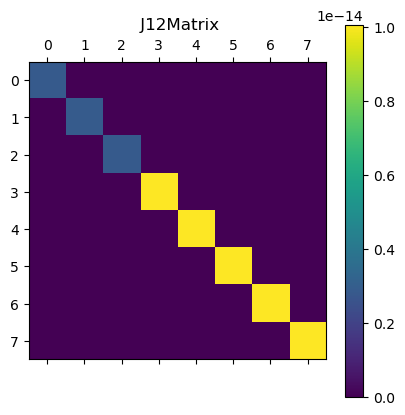

In [12]:
plt.matshow(np.abs(j12), cmap='viridis')
plt.title(" J12Matrix")   
plt.colorbar()
print(((np.diag(j12))))
plt.show()

[2.73914176e-15+6.81384998e-19j 2.73914176e-15+6.81384998e-19j
 2.73914176e-15+6.81384998e-19j 2.13800765e-15-9.85553789e-15j
 2.13800765e-15-9.85553789e-15j 2.13800765e-15-9.85553789e-15j
 2.13800765e-15-9.85553789e-15j 2.13800765e-15-9.85553789e-15j]


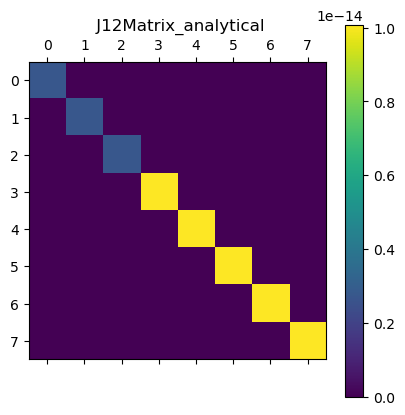

In [14]:
m=1.5
wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
x=k1*600e-9
n_max = 2
modes = sum(2 * n + 1 for n in range(1, n_max + 1))
# modes for exterior region (m,n)
# For a given n m runs from -n to +n
modes_nm = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]
# modes for the interior region (m',n')
modes_nmp = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]
j12_anal = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)
for i in range(0,modes):
    for j in range(0,modes):
        d_zeta_n = x*h1vp(modes_nm[j][0],x)+hankel1(modes_nm[j][0],x)
        psi_n = m*x*spherical_jn(modes_nmp[j][0],m*x)
        j12_anal[i][j]=(1/(k1**2*m))*d_zeta_n*psi_n if modes_nm[j]==modes_nmp[i] else 0

plt.matshow(np.abs(j12_anal), cmap='viridis')
plt.colorbar()
plt.title(" J12Matrix_analytical")
print(np.diag(j12_anal))

In [22]:

def hull_surface_integral_vector(
    function: Callable,
    hull: scipy.spatial.ConvexHull,
    scheme: Any | None = None,
    use_gpu: bool = False,
) -> np.ndarray | cp.ndarray:
    """Compute the integral of a function over the surface of a convex hull. It
    is assumed that the function returns a vector output, i.e. maps R^3 -> R^3.

    function: The function to be integrated. This function must be vectorized
    to accept arguments of shape

    N x n

    where n-1 is the number of dimensions of the simplical facets of the
    surface (alternatively, n is the number of dimensions of the ambient space
    in which the surface lies. For example, for the surface of a sphere, n=3)

    hull: The convex hull object that defines the surface.
    scheme: Integration scheme to be used.
    use_gpu: If true, use cupy instead of numpy
    """
    # Pick appropriate array module
    xp = cp if use_gpu else np

    # Pick integration scheme
    # For future developers: one can use Cayley-Menger determinants for d > 2
    num_dimensions = hull.points.shape[1] - 1
    if num_dimensions > 2:
        raise NotImplementedError(
            "Integration of surfaces in d > 2 dimensions"
            "not currently supported."
        )

    if scheme is None:
        # The second parameter to quadpy's scheme method here is about
        # accuracy of the scheme, not the number of spatial dimensions.
        scheme = quadpy.tn.grundmann_moeller(num_dimensions, 3)

    barycentric_weights = xp.asarray(scheme.points)
    weights = xp.asarray(scheme.weights)
    points = xp.asarray(hull.points)
    vertices = xp.asarray(hull.vertices)
    centroid = xp.mean(points[vertices], axis=0)
    simplices = xp.asarray(hull.simplices)

    # Generate integration points
    num_simplices = len(hull.simplices)
    num_weights = len(weights)
    simplical_points = points[simplices].transpose(0, 2, 1)
    integration_points = simplical_points @ barycentric_weights
    reshaped_points = integration_points.transpose(0, 2, 1).reshape(
        -1, num_dimensions + 1
    )

    # Find simplex volumes using cross product
    v1s = simplical_points[:, :, 1] - simplical_points[:, :, 0]
    v2s = simplical_points[:, :, 2] - simplical_points[:, :, 0]
    cross_products = xp.cross(v1s, v2s)
    unit_normals = cross_products / xp.linalg.norm(
        cross_products, axis=1, keepdims=True
    )
    radial_points = simplical_points[:, :, 0] - centroid
    dot_products = xp.sum(radial_points * unit_normals, axis=1)
    orientation_signs = xp.sign(dot_products)
    areas = 0.5 * xp.sqrt(xp.sum(cross_products**2, axis=1))

    # Output
    function_output = function(reshaped_points)
    integrand = xp.sum(
        function_output.reshape(num_simplices, num_weights, 3)
        * unit_normals[:, None, :],
        axis=2,
    ).reshape(num_simplices * num_weights)
    weighted_output = (
        integrand
        * xp.tile(weights, num_simplices)
        * xp.repeat(areas, num_weights)
        * xp.repeat(orientation_signs, num_weights)
    )
    integral = xp.sum(weighted_output)
    return integral

In [31]:


wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
wavelength2 = 266e-9
k2 = 1.5 * k1
n_max = 2 
row =50
col = 51
num_linear = row * col
theta = np.linspace(0, np.pi, col)
phi = np.linspace(0, 2 * np.pi, row)
r = 600e-9
theta_grid, phi_grid = np.meshgrid(theta, phi)
x = np.reshape((r * np.sin(theta_grid) * np.cos(phi_grid)), (1, num_linear))
y = np.reshape((r * np.sin(theta_grid) * np.sin(phi_grid)), (1, num_linear))
z = np.reshape((r * np.cos(theta_grid)), (1, num_linear))
points = np.transpose(np.vstack((x, y, z)))

# Compute the convex hull
hull = ConvexHull(points)

modes = sum(2 * n + 1 for n in range(1, n_max + 1))

# modes for exterior region (m,n)
# For a given n m runs from -n to +n
modes_nm = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]
# modes for the interior region (m',n')
modes_nmp = [(n, m) for n in range(1, n_max + 1) for m in range(-n, n + 1)]

j12_new_int = np.zeros((len(modes_nmp), len(modes_nm)), dtype=np.complex128)


count = 0
for i in range(0, modes):  # for each mode in the interior region
    for j in tqdm(range(0, modes)):  # for each mode in the exterior region
        """
        print(f"Iteration: {count}")
        print(f"m = {modes_nm[i][1]}")
        print(f"m' = {modes_nmp[j][1]}")
        print(f"n = {modes_nm[i][0]}")
        print(f"n' = {modes_nmp[j][0]}")
        """


        def integrandj12_new(input):

            x,y,z = input[:,0],input[:,1],input[:,2]
            r, theta, phi = cart2sph(x, y, z)

            RgM = RgM_mn(modes_nmp[j][1], modes_nmp[j][0], k2 * r, theta, phi)
            N = N_mn(-modes_nm[i][1], modes_nm[i][0], k1 * r, theta, phi)

            r_comp = RgM[0] * N[2] - RgM[1] * N[1]
            theta_comp = RgM[1] * N[0]
            phi_comp = -RgM[0] * N[0]
            cross_prod = np.array([r_comp, theta_comp, phi_comp])
            cp_cart = sph2cart_comp_vec(
                cross_prod, theta, phi
            )  # do not normalise

            return cp_cart.transpose((1,0))# the output shape should be the same as the input shape

        

        j12_new_int[j][i] = hull_surface_integral_vector(integrandj12_new, hull, use_gpu=False)    

          
            
        j12_new_int[j][i] *= (-1) ** (modes_nm[i][1])





  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:02<00:00,  3.09it/s]


In [26]:
print(np.diag(j12))
print(np.diag(j12_new_int))
print(np.diag(j12_anal))
print(np.abs(np.diag(j12_new_int)-np.diag(j12_anal)))

[2.85607458e-15-2.25985895e-17j 2.88384655e-15-2.90476169e-17j
 2.85607458e-15-2.25985893e-17j 2.04179883e-15-9.85517787e-15j
 2.05400398e-15-9.85571696e-15j 2.05806732e-15-9.85603936e-15j
 2.05400396e-15-9.85571699e-15j 2.04179884e-15-9.85517786e-15j]
[-2.85608611e-15+2.26965295e-17j  2.88385980e-15-2.91869633e-17j
 -2.85608611e-15+2.26965295e-17j  2.04175248e-15-9.85506198e-15j
 -2.05396678e-15+9.85561921e-15j  2.05803341e-15-9.85596783e-15j
 -2.05396678e-15+9.85561921e-15j  2.04175248e-15-9.85506198e-15j]
[2.73914176e-15+6.81384998e-19j 2.73914176e-15+6.81384998e-19j
 2.73914176e-15+6.81384998e-19j 2.13800765e-15-9.85553789e-15j
 2.13800765e-15-9.85553789e-15j 2.13800765e-15-9.85553789e-15j
 2.13800765e-15-9.85553789e-15j 2.13800765e-15-9.85553789e-15j]
[5.59527118e-15 1.47768163e-16 5.59527118e-15 9.62563382e-17
 2.01519816e-14 7.99753920e-17 2.01519816e-14 9.62563382e-17]


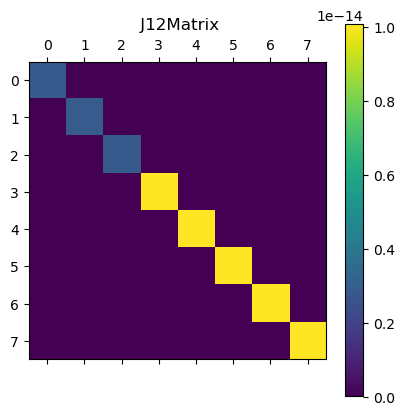

In [32]:
plt.matshow(np.abs(j12_new_int), cmap='viridis')
plt.title(" J12Matrix")   
plt.colorbar()

Text(0.5, 1.0, ' J12Matrix_error')

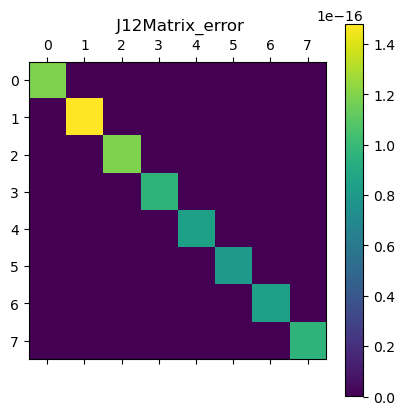

In [35]:
error = np.abs(j12_new_int-j12_anal)
plt.matshow(error, cmap='viridis')
plt.colorbar()
plt.title(" J12Matrix_error")